# Machine Learning - Assignment 2

BITS ID: [2025AC05909]

Name: MADHAN GOPAL H R

Email: [2025ac05909@wilp.bits-pilani.ac.in]

## Section 1: Dataset Loading and Target Preparation

In [34]:
# Install compatible dependencies required for this notebook
%pip install -q numpy==2.0.2 scipy==1.14.1 scikit-learn==1.6.1

In [35]:
### Cell 01

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### Cells 02-04: Define Columns, Load Dataset and Prepare Target

In [36]:
### Cell 02
feature_columns = [
    "X_Minimum",
    "X_Maximum",
    "Y_Minimum",
    "Y_Maximum",
    "Pixels_Areas",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity",
    "Minimum_of_Luminosity",
    "Maximum_of_Luminosity",
    "Length_of_Conveyer",
    "TypeOfSteel_A300",
    "TypeOfSteel_A400",
    "Steel_Plate_Thickness",
    "Edges_Index",
    "Empty_Index",
    "Square_Index",
    "Outside_X_Index",
    "Edges_X_Index",
    "Edges_Y_Index",
    "Outside_Global_Index",
    "LogOfAreas",
    "Log_X_Index",
    "Log_Y_Index",
    "Orientation_Index",
    "Luminosity_Index",
    "SigmoidOfAreas"
]

target_columns = [
    "Pastry",
    "Z_Scratch",
    "K_Scatch",
    "Stains",
    "Dirtiness",
    "Bumps",
    "Other_Faults"
]

all_columns = feature_columns + target_columns

print("Number of input features:", len(feature_columns))
print("Number of target columns:", len(target_columns))
print("Total number of columns:", len(all_columns))

Number of input features: 27
Number of target columns: 7
Total number of columns: 34


In [37]:
### Cell 03

dataset_path = "Faults.NNA"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        "Faults.NNA was not found. Keep Faults.NNA in the same folder "
        "as 2025AC05909_ML_Assignment_02.ipynb."
    )

df_raw = pd.read_csv(
    dataset_path,
    sep=r"\s+",
    header=None,
    names=all_columns
)

print("Dataset loaded successfully.")
print("Dataset file:", dataset_path)
print("Dataset shape:", df_raw.shape)

df_raw.head()

Dataset loaded successfully.
Dataset file: Faults.NNA
Dataset shape: (1941, 34)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,1623,1,0,100,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,1353,0,1,290,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,1353,0,1,185,0.0695,0.4486,0.0662,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [38]:
### Cell 04
# Verify that every record belongs to exactly one fault class
target_sum = df_raw[target_columns].sum(axis=1)

print("Minimum active target columns per row:", target_sum.min())
print("Maximum active target columns per row:", target_sum.max())

if not (target_sum == 1).all():
    raise ValueError(
        "Some rows do not contain exactly one active fault-class label."
    )

# Convert one-hot target columns into one categorical target
df = df_raw[feature_columns].copy()
df["Fault_Type"] = df_raw[target_columns].idxmax(axis=1)

print("\nTarget conversion completed.")
print("Final dataset shape:", df.shape)

df.head()

Minimum active target columns per row: 1
Maximum active target columns per row: 1

Target conversion completed.
Final dataset shape: (1941, 28)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault_Type
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,1623,1,0,100,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,1353,0,1,290,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,1353,0,1,185,0.0695,0.4486,0.0662,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


## Section 2: Dataset Inspection and Data Quality Checks

### Cell 05: Basic Dataset Information

In [39]:
### Cell 05

print("Dataset dimensions:", df.shape)
print("\nColumn data types:")
df.info()

Dataset dimensions: (1941, 28)

Column data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges

In [40]:
### Cell 06

missing_values = df.isnull().sum()
total_missing = missing_values.sum()

duplicate_count = df.duplicated().sum()

print("Total missing values:", total_missing)
print("Number of duplicate records:", duplicate_count)

if total_missing == 0:
    print("No missing values found in the dataset.")
else:
    print("\nColumns containing missing values:")
    print(missing_values[missing_values > 0])

if duplicate_count == 0:
    print("No duplicate records found in the dataset.")
else:
    print("Duplicate records require further inspection.")

Total missing values: 0
Number of duplicate records: 0
No missing values found in the dataset.
No duplicate records found in the dataset.


In [41]:
### Cell 07

df[feature_columns].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454870e+01,3.213430e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869100e+01,37.0000,124.0000,1.270000e+02,1.400000e+02,2.530000e+02


In [42]:
### Cell 08

class_distribution = df["Fault_Type"].value_counts()
class_percentage = (
    df["Fault_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_summary = pd.DataFrame({
    "Number of Records": class_distribution,
    "Percentage (%)": class_percentage
})

class_summary

,Number of Records,Percentage (%)
Fault_Type,,
Other_Faults,673,34.67
Bumps,402,20.71
K_Scatch,391,20.14
Z_Scratch,190,9.79
Pastry,158,8.14
Stains,72,3.71
Dirtiness,55,2.83


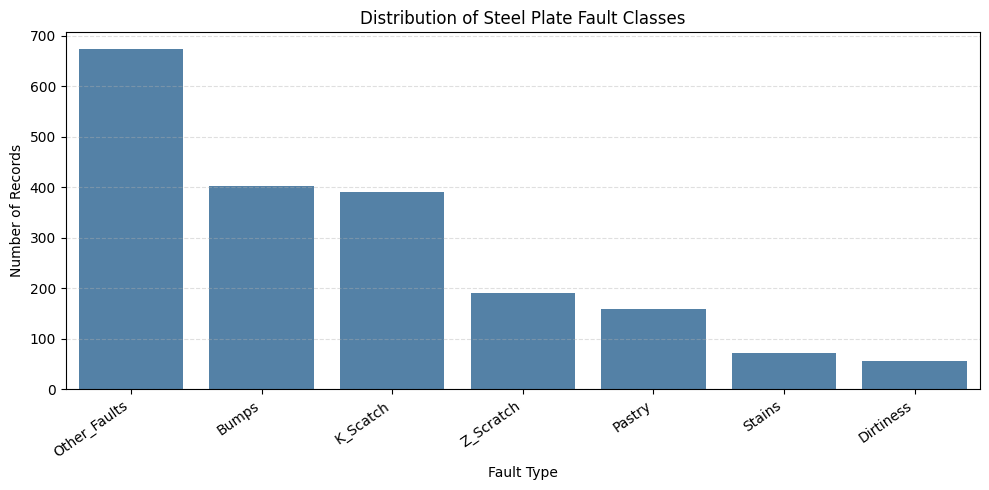

In [43]:
### Cell 09

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Fault_Type",
    order=df["Fault_Type"].value_counts().index,
    color="steelblue"
)

plt.title("Distribution of Steel Plate Fault Classes")
plt.xlabel("Fault Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Section 3: Data Preparation and Train-Test Split

### Cell 10: Import Preprocessing Utilities

In [44]:
### Cell 10

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [45]:
### Cell 11

X = df[feature_columns].copy()
y = df["Fault_Type"].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget classes:")
print(sorted(y.unique()))

Feature matrix shape: (1941, 27)
Target vector shape: (1941,)

Target classes:
['Bumps', 'Dirtiness', 'K_Scatch', 'Other_Faults', 'Pastry', 'Stains', 'Z_Scratch']


In [46]:
### Cell 12

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = {
    class_name: encoded_value
    for encoded_value, class_name in enumerate(label_encoder.classes_)
}

print("Target encoding completed.")
print("\nClass mapping:")

for class_name, encoded_value in class_mapping.items():
    print(f"{encoded_value} -> {class_name}")

Target encoding completed.

Class mapping:
0 -> Bumps
1 -> Dirtiness
2 -> K_Scatch
3 -> Other_Faults
4 -> Pastry
5 -> Stains
6 -> Z_Scratch


In [47]:
### Cell 13

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (1552, 27)
Testing feature shape: (389, 27)
Training target shape: (1552,)
Testing target shape: (389,)


In [48]:
### Cell 14

train_distribution = pd.Series(
    label_encoder.inverse_transform(y_train)
).value_counts(normalize=True).sort_index().mul(100).round(2)

test_distribution = pd.Series(
    label_encoder.inverse_transform(y_test)
).value_counts(normalize=True).sort_index().mul(100).round(2)

distribution_comparison = pd.DataFrame({
    "Training Set (%)": train_distribution,
    "Testing Set (%)": test_distribution
})

distribution_comparison

,Training Set (%),Testing Set (%)
Bumps,20.68,20.82
Dirtiness,2.84,2.83
K_Scatch,20.17,20.05
Other_Faults,34.66,34.70
Pastry,8.12,8.23
Stains,3.74,3.60
Z_Scratch,9.79,9.77


In [49]:
### Cell 15

test_data = X_test.copy()
test_data["Fault_Type"] = label_encoder.inverse_transform(y_test)

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv created successfully.")
print("Test-data shape:", test_data.shape)

test_data.head()

test_data.csv created successfully.
Test-data shape: (389, 28)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault_Type
1710,833,856,937709,937842,1058,142,151,132331,112,143,1396,0,1,220,0.7736,0.6541,0.1729,0.0165,0.1620,0.8808,1.0,3.0245,1.3617,2.1239,0.8271,-0.0228,1.0000,Other_Faults
863,614,622,2215716,2215730,68,13,14,7990,109,133,1364,0,1,100,0.9003,0.3929,0.5714,0.0059,0.6154,1.0000,1.0,1.8325,0.9031,1.1461,0.4286,-0.0820,0.2195,Dirtiness
1174,1031,1045,621518,621530,115,15,12,11562,68,127,1688,1,0,70,0.7618,0.3155,0.8571,0.0083,0.9333,1.0000,0.0,2.0607,1.1461,1.0792,-0.1429,-0.2145,0.2901,Bumps
1815,550,558,2426501,2426519,109,15,18,12587,103,135,1708,1,0,100,0.6440,0.2431,0.4444,0.0047,0.5333,1.0000,1.0,2.0374,0.9031,1.2553,0.5556,-0.0978,0.2583,Other_Faults
370,945,956,508640,508650,85,12,10,14041,139,181,1387,0,1,40,0.6215,0.2273,0.9091,0.0079,0.9167,1.0000,0.0,1.9294,1.0414,1.0000,-0.0909,0.2905,0.2173,K_Scatch


## Section 4: Model Evaluation Function

In [50]:
### Cell 16

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("Model and evaluation libraries imported successfully.")

Model and evaluation libraries imported successfully.


In [51]:
### Cell 17

model_results = []
trained_models = {}

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a multiclass classification model.
    """

    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions and class probabilities
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_probability,
        multi_class="ovr",
        average="weighted"
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(y_test, y_pred)

    # Store results
    result = {
        "ML Model Name": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    }

    model_results.append(result)
    trained_models[model_name] = model

    # Display evaluation metrics
    metrics_table = pd.DataFrame([result]).set_index("ML Model Name")

    print(f"{model_name} trained and evaluated successfully.\n")
    display(metrics_table.round(4))

    # Display classification report
    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted Fault Class")
    plt.ylabel("Actual Fault Class")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return y_pred

## Section 5: Logistic Regression

Logistic Regression trained and evaluated successfully.



,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.7275,0.9066,0.7329,0.7275,0.7277,0.6487



Classification Report:

              precision    recall  f1-score   support

       Bumps       0.69      0.57      0.62        81
   Dirtiness       0.88      0.64      0.74        11
    K_Scatch       0.95      0.91      0.93        78
Other_Faults       0.64      0.71      0.68       135
      Pastry       0.51      0.56      0.54        32
      Stains       0.86      0.86      0.86        14
   Z_Scratch       0.80      0.87      0.84        38

    accuracy                           0.73       389
   macro avg       0.76      0.73      0.74       389
weighted avg       0.73      0.73      0.73       389



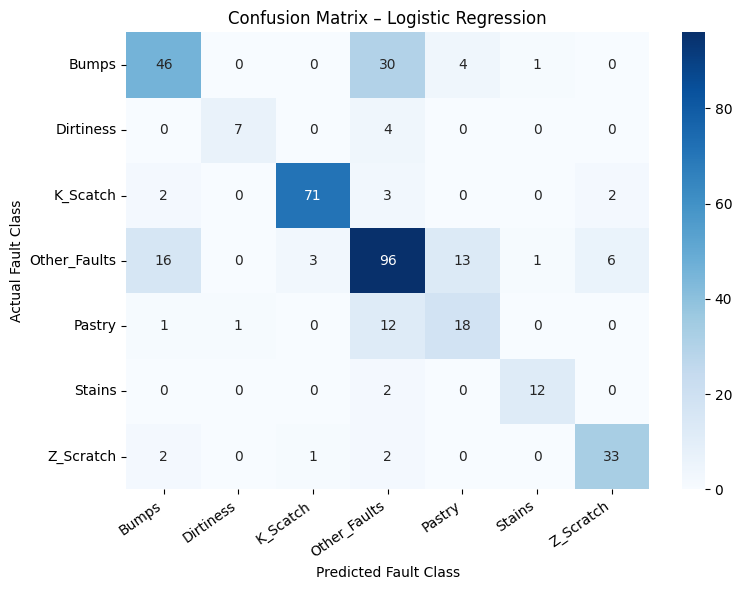

In [52]:
### Cell 18

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            random_state=42
        )
    )
])

logistic_predictions = evaluate_model(
    model_name="Logistic Regression",
    model=logistic_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## Section 6: Decision Tree Classifier

Decision Tree trained and evaluated successfully.



,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Decision Tree,0.7455,0.8313,0.7492,0.7455,0.7452,0.6733



Classification Report:

              precision    recall  f1-score   support

       Bumps       0.66      0.68      0.67        81
   Dirtiness       0.77      0.91      0.83        11
    K_Scatch       0.99      0.85      0.91        78
Other_Faults       0.70      0.72      0.71       135
      Pastry       0.50      0.44      0.47        32
      Stains       0.79      0.79      0.79        14
   Z_Scratch       0.82      0.97      0.89        38

    accuracy                           0.75       389
   macro avg       0.75      0.76      0.75       389
weighted avg       0.75      0.75      0.75       389



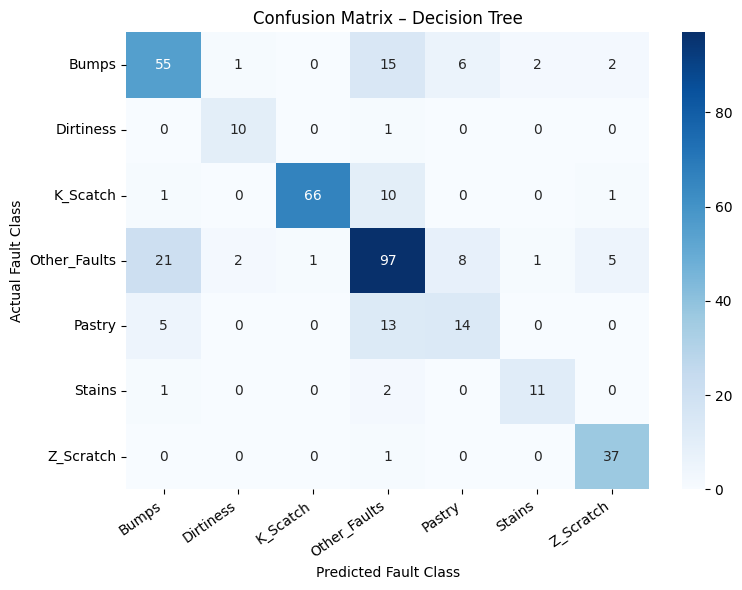

In [53]:
### Cell 19

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_predictions = evaluate_model(
    model_name="Decision Tree",
    model=decision_tree_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## Section 7: K-Nearest Neighbours

K-Nearest Neighbours trained and evaluated successfully.



,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
K-Nearest Neighbours,0.7275,0.8941,0.7318,0.7275,0.7245,0.6548



Classification Report:

              precision    recall  f1-score   support

       Bumps       0.56      0.72      0.63        81
   Dirtiness       0.90      0.82      0.86        11
    K_Scatch       0.96      0.96      0.96        78
Other_Faults       0.72      0.61      0.66       135
      Pastry       0.55      0.38      0.44        32
      Stains       0.75      0.86      0.80        14
   Z_Scratch       0.79      0.89      0.84        38

    accuracy                           0.73       389
   macro avg       0.75      0.75      0.74       389
weighted avg       0.73      0.73      0.72       389



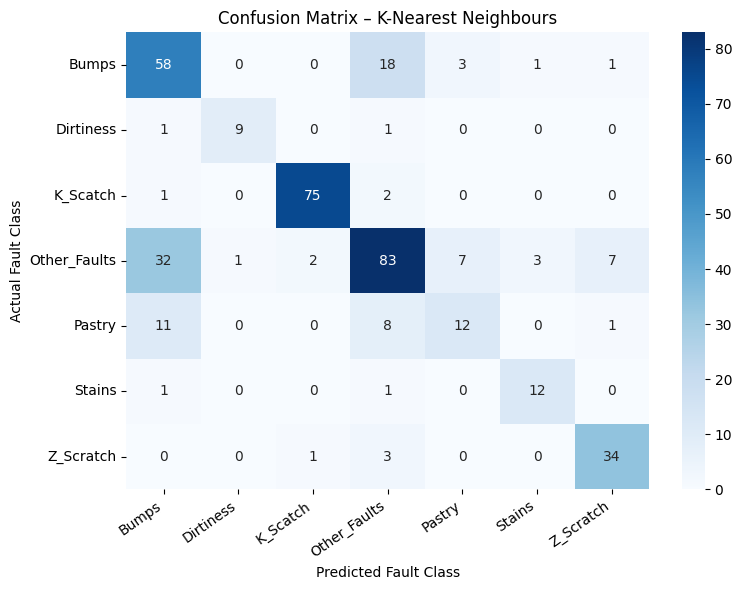

In [54]:
### Cell 20

from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

knn_predictions = evaluate_model(
    model_name="K-Nearest Neighbours",
    model=knn_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## Section 8: Gaussian Naive Bayes

Gaussian Naive Bayes trained and evaluated successfully.



,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Gaussian Naive Bayes,0.4524,0.7955,0.5741,0.4524,0.4003,0.3789



Classification Report:

              precision    recall  f1-score   support

       Bumps       0.33      0.74      0.45        81
   Dirtiness       0.07      0.09      0.08        11
    K_Scatch       0.89      0.74      0.81        78
Other_Faults       0.74      0.10      0.18       135
      Pastry       0.17      0.03      0.05        32
      Stains       0.41      0.86      0.56        14
   Z_Scratch       0.42      0.79      0.55        38

    accuracy                           0.45       389
   macro avg       0.43      0.48      0.38       389
weighted avg       0.57      0.45      0.40       389



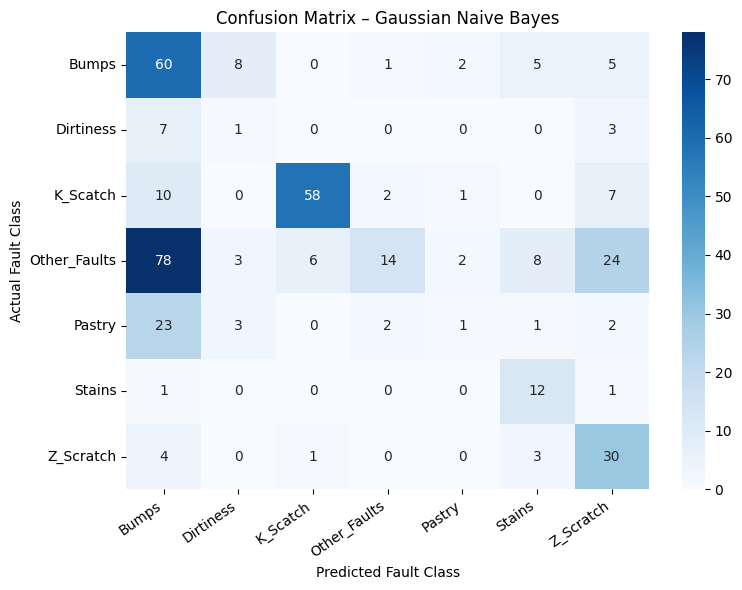

In [55]:
### Cell 21

from sklearn.naive_bayes import GaussianNB

naive_bayes_model = GaussianNB()

naive_bayes_predictions = evaluate_model(
    model_name="Gaussian Naive Bayes",
    model=naive_bayes_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## Section 9: Random Forest Classifier

Random Forest trained and evaluated successfully.



,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Random Forest,0.8021,0.9468,0.8087,0.8021,0.8016,0.7434



Classification Report:

              precision    recall  f1-score   support

       Bumps       0.74      0.70      0.72        81
   Dirtiness       0.90      0.82      0.86        11
    K_Scatch       0.97      0.91      0.94        78
Other_Faults       0.72      0.84      0.78       135
      Pastry       0.70      0.50      0.58        32
      Stains       0.92      0.86      0.89        14
   Z_Scratch       0.97      0.87      0.92        38

    accuracy                           0.80       389
   macro avg       0.85      0.79      0.81       389
weighted avg       0.81      0.80      0.80       389



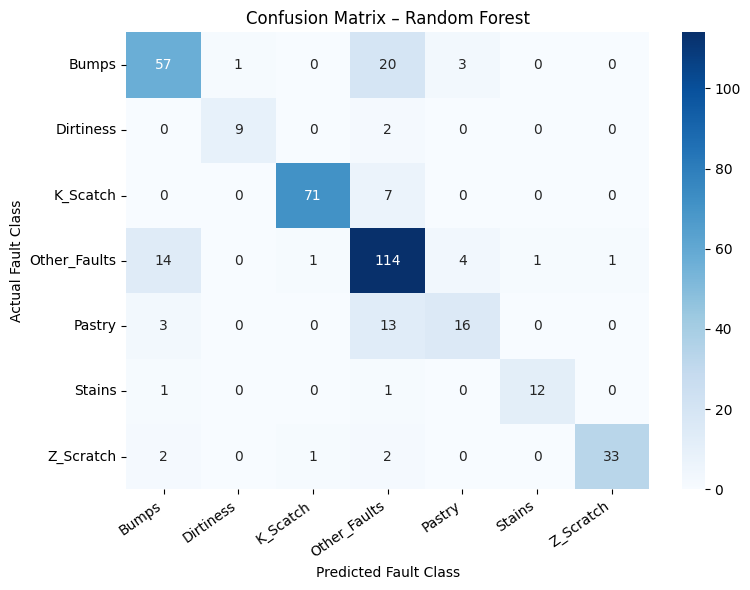

In [56]:
### Cell 22

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_predictions = evaluate_model(
    model_name="Random Forest",
    model=random_forest_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## Section 10: Final Model Comparison

In [57]:
### Cell 23

model_order = [
    "Logistic Regression",
    "Decision Tree",
    "K-Nearest Neighbours",
    "Gaussian Naive Bayes",
    "Random Forest"
]

comparison_table = (
    pd.DataFrame(model_results)
    .drop_duplicates(subset="ML Model Name", keep="last")
    .set_index("ML Model Name")
    .reindex(model_order)
    .round(4)
)

comparison_table

,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.7275,0.9066,0.7329,0.7275,0.7277,0.6487
Decision Tree,0.7455,0.8313,0.7492,0.7455,0.7452,0.6733
K-Nearest Neighbours,0.7275,0.8941,0.7318,0.7275,0.7245,0.6548
Gaussian Naive Bayes,0.4524,0.7955,0.5741,0.4524,0.4003,0.3789
Random Forest,0.8021,0.9468,0.8087,0.8021,0.8016,0.7434


In [58]:
### Cell 24

winner_name = comparison_table["F1"].idxmax()
winner_results = comparison_table.loc[winner_name]

print("Overall winning model:", winner_name)
print("\nWinning model performance:")
display(winner_results.to_frame(name="Score"))

Overall winning model: Random Forest

Winning model performance:


,Score
Accuracy,0.8021
AUC,0.9468
Precision,0.8087
Recall,0.8021
F1,0.8016
MCC,0.7434


In [59]:
### Cell 25

comparison_table.to_csv("model_comparison.csv")

print("model_comparison.csv created successfully.")

model_comparison.csv created successfully.


## Section 11: Model Performance Observations

In [60]:
### Cell 26

model_observations = pd.DataFrame({
    "ML Model Name": [
        "Logistic Regression",
        "Decision Tree",
        "K-Nearest Neighbours",
        "Gaussian Naive Bayes",
        "Random Forest",
        "Overall Winner"
    ],
    "Observation about Model Performance": [
        (
            "Achieved moderate and balanced performance with 72.75% accuracy "
            "and a strong AUC of 0.9066. It performed well for K_Scatch, "
            "Stains and Z_Scratch, but showed confusion among Bumps, "
            "Other_Faults and Pastry."
        ),
        (
            "Achieved 74.55% accuracy and performed better than Logistic "
            "Regression in Accuracy, F1 and MCC. However, its lower AUC of "
            "0.8313 indicates less reliable probability-based class separation."
        ),
        (
            "Achieved 72.75% accuracy and an AUC of 0.8941. Scaling improved "
            "distance calculations, but the model had difficulty distinguishing "
            "Other_Faults and Pastry from Bumps."
        ),
        (
            "Produced the lowest performance with 45.24% accuracy and an F1 "
            "score of 0.4003. Its conditional-independence and Gaussian "
            "distribution assumptions are unsuitable for the correlated "
            "steel-plate measurements."
        ),
        (
            "Achieved the best values for all evaluation metrics, including "
            "80.21% accuracy, 0.9468 AUC, 0.8016 F1 and 0.7434 MCC. The ensemble "
            "captured nonlinear relationships and reduced individual-tree variance."
        ),
        (
            "Random Forest is the overall winner because it achieved the highest "
            "Accuracy, AUC, Precision, Recall, F1 and MCC on the test dataset."
        )
    ]
})

pd.set_option("display.max_colwidth", None)

model_observations

,ML Model Name,Observation about Model Performance
0,Logistic Regression,"Achieved moderate and balanced performance with 72.75% accuracy and a strong AUC of 0.9066. It performed well for K_Scatch, Stains and Z_Scratch, but showed confusion among Bumps, Other_Faults and Pastry."
1,Decision Tree,"Achieved 74.55% accuracy and performed better than Logistic Regression in Accuracy, F1 and MCC. However, its lower AUC of 0.8313 indicates less reliable probability-based class separation."
2,K-Nearest Neighbours,"Achieved 72.75% accuracy and an AUC of 0.8941. Scaling improved distance calculations, but the model had difficulty distinguishing Other_Faults and Pastry from Bumps."
3,Gaussian Naive Bayes,Produced the lowest performance with 45.24% accuracy and an F1 score of 0.4003. Its conditional-independence and Gaussian distribution assumptions are unsuitable for the correlated steel-plate measurements.
4,Random Forest,"Achieved the best values for all evaluation metrics, including 80.21% accuracy, 0.9468 AUC, 0.8016 F1 and 0.7434 MCC. The ensemble captured nonlinear relationships and reduced individual-tree variance."
5,Overall Winner,"Random Forest is the overall winner because it achieved the highest Accuracy, AUC, Precision, Recall, F1 and MCC on the test dataset."


## Section 12: Save Trained Models

In [61]:
### Cell 27

import os
import joblib

os.makedirs("model", exist_ok=True)

model_filenames = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "K-Nearest Neighbours": "knn.pkl",
    "Gaussian Naive Bayes": "gaussian_naive_bayes.pkl",
    "Random Forest": "random_forest.pkl"
}

for model_name, filename in model_filenames.items():
    model_path = os.path.join("model", filename)
    joblib.dump(trained_models[model_name], model_path)
    print(f"Saved: {model_path}")

joblib.dump(label_encoder, "model/label_encoder.pkl")
joblib.dump(feature_columns, "model/feature_columns.pkl")

print("\nLabel encoder and feature-column list saved successfully.")

Saved: model/logistic_regression.pkl
Saved: model/decision_tree.pkl
Saved: model/knn.pkl
Saved: model/gaussian_naive_bayes.pkl
Saved: model/random_forest.pkl

Label encoder and feature-column list saved successfully.


In [62]:
### Cell 28

print("Files available inside the model folder:\n")

for filename in sorted(os.listdir("model")):
    file_path = os.path.join("model", filename)
    file_size_kb = os.path.getsize(file_path) / 1024

    print(f"{filename}: {file_size_kb:.2f} KB")

Files available inside the model folder:

decision_tree.pkl: 62.59 KB
feature_columns.pkl: 0.46 KB
gaussian_naive_bayes.pkl: 4.53 KB
knn.pkl: 342.09 KB
label_encoder.pkl: 0.54 KB
logistic_regression.pkl: 4.20 KB
random_forest.pkl: 17755.81 KB


## Section 13: Streamlit Application and Deployment

The trained classification models were integrated into a Streamlit web
application. The application provides CSV test-data upload, model selection,
six evaluation metrics, confusion matrix, classification report and
downloadable prediction results.

The complete Streamlit source code (`app.py`), dependencies
(`requirements.txt`), test dataset and saved model files are maintained in the
GitHub repository. The application is deployed using Streamlit Community
Cloud.

**GitHub Repository:**  
https://github.com/2025ac05909/steel-plate-fault-classification

**Live Streamlit Application:**  
https://steelsight-ai-2025ac05909.streamlit.app